<a href="https://colab.research.google.com/github/FrancinaDharshini/DAA-Lab/blob/main/1B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  DAA Lab: Interpolation Search vs Binary Search
  Sorted roll numbers: 1 to 10000

── Demo search for roll number 7654 ──

INTERPOLATION SEARCH  (1 probes):
  Probe 1: pos=7653, arr[pos]=7654, range=[0,9999]
  ✓ Found at index 7653

BINARY SEARCH  (13 probes):
  Probe 1: mid=4999, arr[mid]=5000, range=[0,9999]
  Probe 2: mid=7499, arr[mid]=7500, range=[5000,9999]
  Probe 3: mid=8749, arr[mid]=8750, range=[7500,9999]
  Probe 4: mid=8124, arr[mid]=8125, range=[7500,8748]
  Probe 5: mid=7811, arr[mid]=7812, range=[7500,8123]
  Probe 6: mid=7655, arr[mid]=7656, range=[7500,7810]
  Probe 7: mid=7577, arr[mid]=7578, range=[7500,7654]
  Probe 8: mid=7616, arr[mid]=7617, range=[7578,7654]
  Probe 9: mid=7635, arr[mid]=7636, range=[7617,7654]
  Probe 10: mid=7645, arr[mid]=7646, range=[7636,7654]
  Probe 11: mid=7650, arr[mid]=7651, range=[7646,7654]
  Probe 12: mid=7652, arr[mid]=7653, range=[7651,7654]
  Probe 13: mid=7653, arr[mid]=7654, range=[7653,7654]
  ✓ Found at index 7653

── Probe c

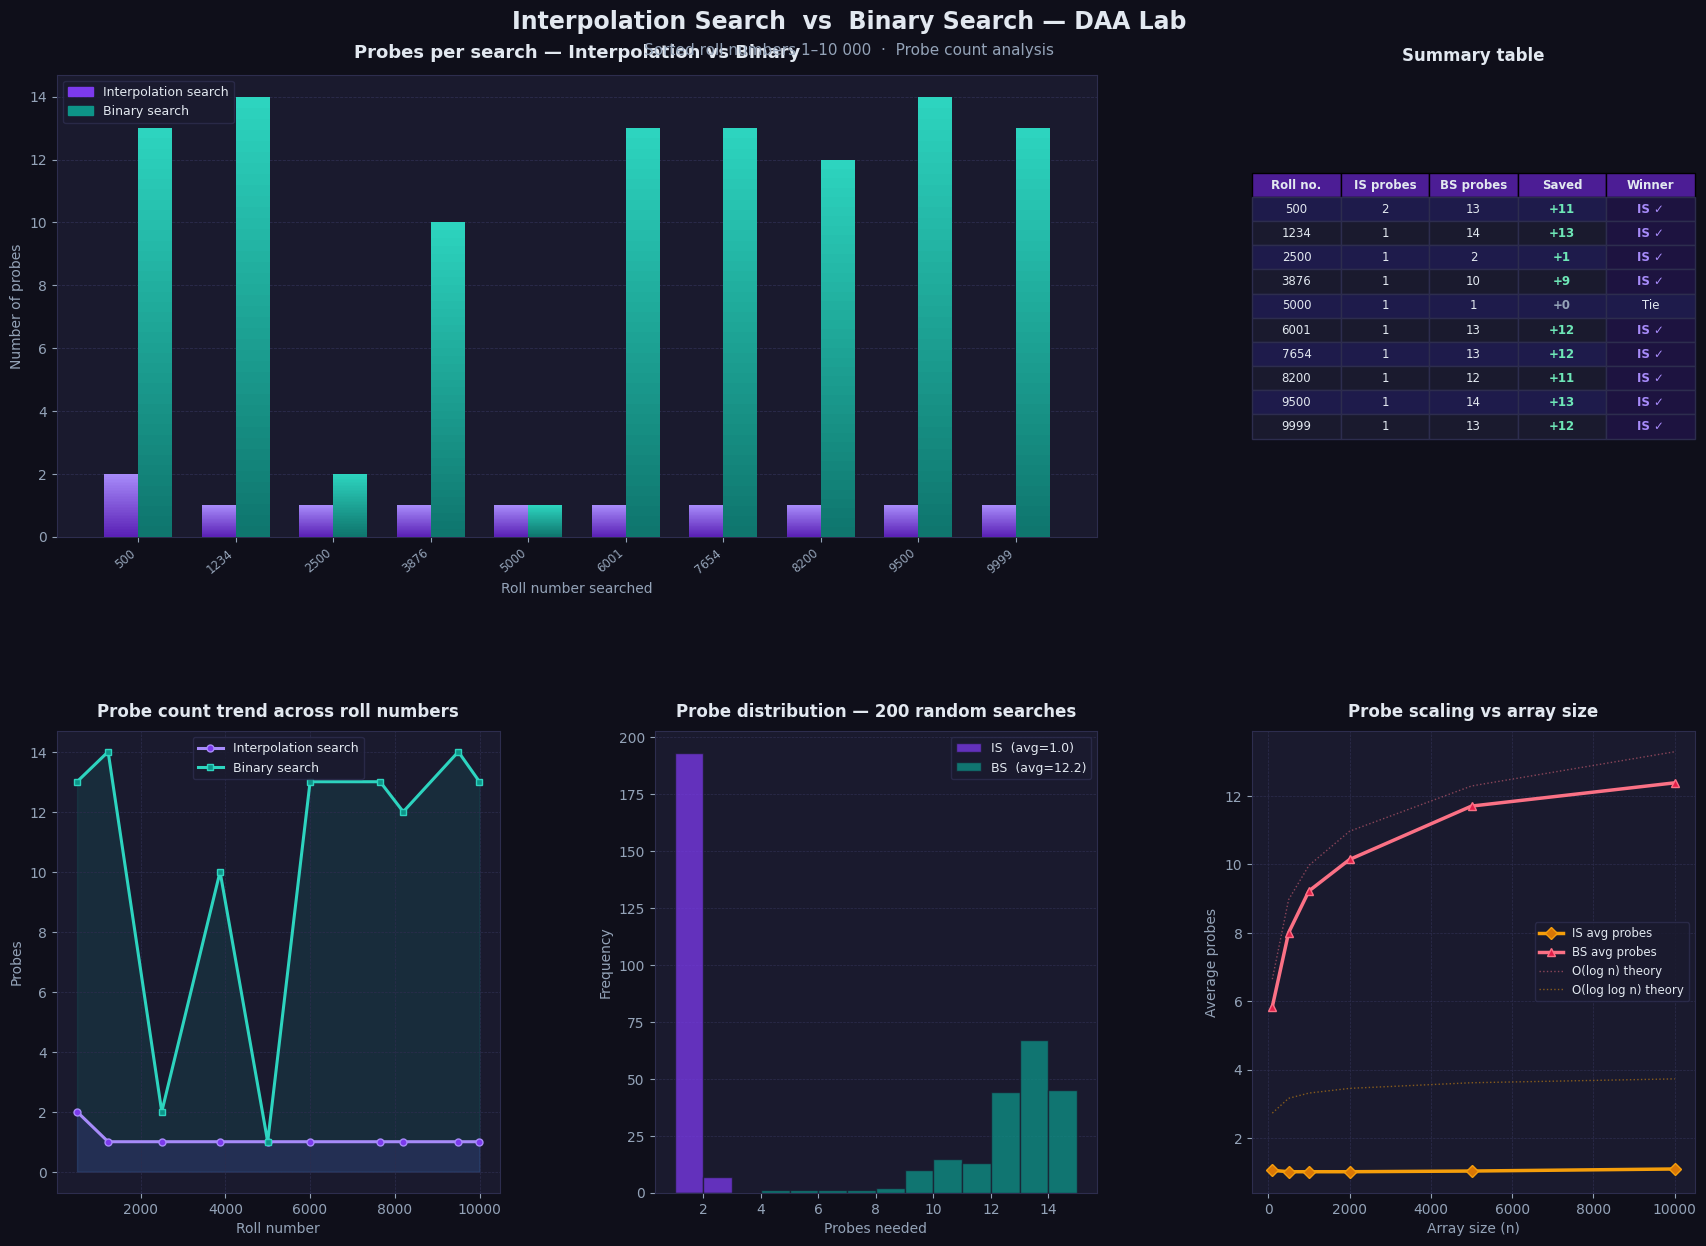

In [3]:
"""
DAA Lab — Interpolation Search vs Binary Search
Sorted array of student roll numbers (1 to 10000)
Counts probes and compares both algorithms with rich visualizations.
"""

import math
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator

# ─────────────────────────────────────────────
#  ALGORITHM IMPLEMENTATIONS
# ─────────────────────────────────────────────

def interpolation_search(arr, target):
    """
    Interpolation Search — estimates probe position by linear interpolation.
    Best for uniformly distributed sorted arrays.
    Average: O(log log n)  |  Worst: O(n)
    """
    lo, hi = 0, len(arr) - 1
    probes = 0
    trace = []

    while lo <= hi and arr[lo] <= target <= arr[hi]:
        probes += 1
        denom = arr[hi] - arr[lo]

        if denom == 0:
            trace.append(f"  Probe {probes}: lo == hi, arr[lo] = {arr[lo]}")
            if arr[lo] == target:
                return lo, probes, trace + [f"  ✓ Found at index {lo}"]
            break

        # The key formula: position estimate by interpolation
        pos = lo + int(((target - arr[lo]) / denom) * (hi - lo))
        pos = max(lo, min(hi, pos))   # clamp for safety
        trace.append(f"  Probe {probes}: pos={pos}, arr[pos]={arr[pos]}, range=[{lo},{hi}]")

        if arr[pos] == target:
            return pos, probes, trace + [f"  ✓ Found at index {pos}"]
        elif arr[pos] < target:
            lo = pos + 1
        else:
            hi = pos - 1

    return -1, probes, trace + [f"  ✗ Not found"]


def binary_search(arr, target):
    """
    Binary Search — always probes the midpoint of the current range.
    Average & Best: O(log n)  |  Worst: O(log n)
    """
    lo, hi = 0, len(arr) - 1
    probes = 0
    trace = []

    while lo <= hi:
        probes += 1
        mid = lo + (hi - lo) // 2
        trace.append(f"  Probe {probes}: mid={mid}, arr[mid]={arr[mid]}, range=[{lo},{hi}]")

        if arr[mid] == target:
            return mid, probes, trace + [f"  ✓ Found at index {mid}"]
        elif arr[mid] < target:
            lo = mid + 1
        else:
            hi = mid - 1

    return -1, probes, trace + [f"  ✗ Not found"]


# ─────────────────────────────────────────────
#  DATA GENERATION
# ─────────────────────────────────────────────

def build_roll_array(n=10000):
    """Sorted unique roll numbers from 1 to 10000."""
    return list(range(1, n + 1))


def run_comparison(targets, arr):
    """Run both algorithms on a list of targets, collect probe counts."""
    is_probes, bs_probes = [], []
    for t in targets:
        _, ip, _ = interpolation_search(arr, t)
        _, bp, _ = binary_search(arr, t)
        is_probes.append(ip)
        bs_probes.append(bp)
    return is_probes, bs_probes


# ─────────────────────────────────────────────
#  VISUALIZATIONS
# ─────────────────────────────────────────────

PURPLE  = "#7C3AED"
TEAL    = "#0D9488"
GOLD    = "#D97706"
ROSE    = "#E11D48"
BG      = "#0F0F1A"
PANEL   = "#1A1A2E"
BORDER  = "#2D2D4E"
TEXT    = "#E2E8F0"
SUBTEXT = "#94A3B8"


def make_gradient_bar(ax, x, height, color_top, color_bot, width=0.35, offset=0):
    """Draw a bar with a vertical gradient using stacked thin rectangles."""
    n = 40
    grad = np.linspace(0, 1, n)
    top = np.array([int(color_top[i:i+2], 16) for i in (1, 3, 5)])
    bot = np.array([int(color_bot[i:i+2], 16) for i in (1, 3, 5)])
    seg_h = height / n if height > 0 else 0
    for i, g in enumerate(grad):
        c = bot + (top - bot) * g
        hex_c = "#{:02X}{:02X}{:02X}".format(int(c[0]), int(c[1]), int(c[2]))
        ax.bar(x + offset, seg_h, bottom=i * seg_h, width=width,
               color=hex_c, linewidth=0, zorder=3)


def plot_main_comparison(ax, targets, is_probes, bs_probes):
    """Grouped gradient bar chart: IS vs BS probes for each target."""
    ax.set_facecolor(PANEL)
    x = np.arange(len(targets))
    w = 0.35

    for i, (t, ip, bp) in enumerate(zip(targets, is_probes, bs_probes)):
        make_gradient_bar(ax, i, ip, "#A78BFA", "#5B21B6", width=w, offset=-w/2)
        make_gradient_bar(ax, i, bp, "#2DD4BF", "#0F766E", width=w, offset= w/2)

    ax.set_xticks(x)
    ax.set_xticklabels([str(t) for t in targets], rotation=40, ha='right',
                       color=TEXT, fontsize=8.5)
    ax.set_ylabel("Number of probes", color=SUBTEXT, fontsize=10)
    ax.set_xlabel("Roll number searched", color=SUBTEXT, fontsize=10)
    ax.set_title("Probes per search — Interpolation vs Binary", color=TEXT,
                 fontsize=13, fontweight='bold', pad=12)
    ax.tick_params(colors=SUBTEXT)
    ax.spines[:].set_color(BORDER)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(axis='y', color=BORDER, linewidth=0.6, linestyle='--', zorder=0)

    p1 = mpatches.Patch(color="#7C3AED", label="Interpolation search")
    p2 = mpatches.Patch(color="#0D9488", label="Binary search")
    ax.legend(handles=[p1, p2], facecolor=PANEL, edgecolor=BORDER,
              labelcolor=TEXT, fontsize=9, loc='upper left')


def plot_line_trend(ax, targets, is_probes, bs_probes):
    """Smooth line chart showing probe trend across roll numbers."""
    ax.set_facecolor(PANEL)
    ax.plot(targets, is_probes, color="#A78BFA", linewidth=2.2, marker='o',
            markersize=5, markerfacecolor="#7C3AED", label="Interpolation search", zorder=4)
    ax.plot(targets, bs_probes, color="#2DD4BF", linewidth=2.2, marker='s',
            markersize=5, markerfacecolor="#0D9488", label="Binary search", zorder=4)

    ax.fill_between(targets, is_probes, alpha=0.15, color="#7C3AED")
    ax.fill_between(targets, bs_probes, alpha=0.15, color="#0D9488")

    ax.set_title("Probe count trend across roll numbers", color=TEXT,
                 fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("Roll number", color=SUBTEXT, fontsize=10)
    ax.set_ylabel("Probes", color=SUBTEXT, fontsize=10)
    ax.tick_params(colors=SUBTEXT)
    ax.spines[:].set_color(BORDER)
    ax.grid(color=BORDER, linewidth=0.5, linestyle='--')
    ax.legend(facecolor=PANEL, edgecolor=BORDER, labelcolor=TEXT, fontsize=9)


def plot_probe_distribution(ax, arr):
    """Histogram of IS vs BS probe counts across many random searches."""
    random.seed(42)
    samples = random.sample(arr, 200)
    is_all = [interpolation_search(arr, t)[1] for t in samples]
    bs_all = [binary_search(arr, t)[1] for t in samples]

    ax.set_facecolor(PANEL)
    bins = range(1, max(max(is_all), max(bs_all)) + 2)
    ax.hist(is_all, bins=bins, color="#7C3AED", alpha=0.75,
            label=f"IS  (avg={sum(is_all)/len(is_all):.1f})", edgecolor=PANEL, zorder=3)
    ax.hist(bs_all, bins=bins, color="#0D9488", alpha=0.75,
            label=f"BS  (avg={sum(bs_all)/len(bs_all):.1f})", edgecolor=PANEL, zorder=3)

    ax.set_title("Probe distribution — 200 random searches", color=TEXT,
                 fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("Probes needed", color=SUBTEXT, fontsize=10)
    ax.set_ylabel("Frequency", color=SUBTEXT, fontsize=10)
    ax.tick_params(colors=SUBTEXT)
    ax.spines[:].set_color(BORDER)
    ax.grid(axis='y', color=BORDER, linewidth=0.5, linestyle='--')
    ax.legend(facecolor=PANEL, edgecolor=BORDER, labelcolor=TEXT, fontsize=9)


def plot_array_size_scaling(ax):
    """How probes scale with array size (theoretical + empirical)."""
    sizes = [100, 500, 1000, 2000, 5000, 10000]
    is_avg, bs_avg = [], []

    for n in sizes:
        arr = list(range(1, n + 1))
        samples = random.sample(arr, min(50, n))
        is_p = [interpolation_search(arr, t)[1] for t in samples]
        bs_p = [binary_search(arr, t)[1] for t in samples]
        is_avg.append(sum(is_p) / len(is_p))
        bs_avg.append(sum(bs_p) / len(bs_p))

    ax.set_facecolor(PANEL)
    ax.plot(sizes, is_avg, color="#F59E0B", linewidth=2.5, marker='D',
            markersize=6, markerfacecolor="#D97706", label="IS avg probes", zorder=4)
    ax.plot(sizes, bs_avg, color="#FB7185", linewidth=2.5, marker='^',
            markersize=6, markerfacecolor="#E11D48", label="BS avg probes", zorder=4)

    # Theoretical reference lines
    x_ref = np.array(sizes, dtype=float)
    log2_n = np.log2(x_ref)
    loglog_n = np.log2(np.log2(x_ref))
    ax.plot(sizes, log2_n, color="#FB7185", linewidth=1, linestyle=':', alpha=0.5, label="O(log n) theory")
    ax.plot(sizes, loglog_n, color="#F59E0B", linewidth=1, linestyle=':', alpha=0.5, label="O(log log n) theory")

    ax.set_title("Probe scaling vs array size", color=TEXT,
                 fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("Array size (n)", color=SUBTEXT, fontsize=10)
    ax.set_ylabel("Average probes", color=SUBTEXT, fontsize=10)
    ax.tick_params(colors=SUBTEXT)
    ax.spines[:].set_color(BORDER)
    ax.grid(color=BORDER, linewidth=0.5, linestyle='--')
    ax.legend(facecolor=PANEL, edgecolor=BORDER, labelcolor=TEXT, fontsize=8.5)


def plot_summary_table(ax, targets, is_probes, bs_probes):
    """Color-coded summary table."""
    ax.set_facecolor(PANEL)
    ax.axis('off')
    ax.set_title("Summary table", color=TEXT, fontsize=12, fontweight='bold', pad=10)

    col_labels = ["Roll no.", "IS probes", "BS probes", "Saved", "Winner"]
    rows = []
    for t, ip, bp in zip(targets, is_probes, bs_probes):
        saved = bp - ip
        winner = "IS ✓" if ip < bp else ("BS ✓" if bp < ip else "Tie")
        rows.append([str(t), str(ip), str(bp), f"{saved:+d}", winner])

    table = ax.table(cellText=rows, colLabels=col_labels,
                     cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(8.5)
    table.scale(1, 1.45)

    for j in range(len(col_labels)):
        table[0, j].set_facecolor("#4C1D95")
        table[0, j].set_text_props(color=TEXT, fontweight='bold')

    for i, row in enumerate(rows):
        winner_val = row[4]
        for j in range(len(col_labels)):
            cell = table[i+1, j]
            cell.set_facecolor("#1E1B4B" if i % 2 == 0 else PANEL)
            if j == 4:
                if "IS" in winner_val:
                    cell.set_facecolor("#1D1340")
                    cell.set_text_props(color="#A78BFA", fontweight='bold')
                elif "BS" in winner_val:
                    cell.set_facecolor("#0C2620")
                    cell.set_text_props(color="#2DD4BF", fontweight='bold')
            elif j == 3:
                saved_n = int(row[3])
                color = "#6EE7B7" if saved_n > 0 else ("#FCA5A5" if saved_n < 0 else SUBTEXT)
                cell.set_text_props(color=color, fontweight='bold')
            else:
                cell.set_text_props(color=TEXT)
            cell.set_edgecolor(BORDER)


# ─────────────────────────────────────────────
#  MAIN
# ─────────────────────────────────────────────

def main():
    print("=" * 60)
    print("  DAA Lab: Interpolation Search vs Binary Search")
    print("  Sorted roll numbers: 1 to 10000")
    print("=" * 60)

    arr = build_roll_array(10000)

    demo_target = 7654
    print(f"\n── Demo search for roll number {demo_target} ──\n")

    idx_is, p_is, trace_is = interpolation_search(arr, demo_target)
    print(f"INTERPOLATION SEARCH  ({p_is} probes):")
    for line in trace_is:
        print(line)

    idx_bs, p_bs, trace_bs = binary_search(arr, demo_target)
    print(f"\nBINARY SEARCH  ({p_bs} probes):")
    for line in trace_bs:
        print(line)

    targets = [500, 1234, 2500, 3876, 5000, 6001, 7654, 8200, 9500, 9999]
    is_probes, bs_probes = run_comparison(targets, arr)

    print("\n── Probe comparison table ──")
    print(f"{'Roll No':>10} {'IS Probes':>12} {'BS Probes':>12} {'Winner':>10}")
    print("-" * 46)
    for t, ip, bp in zip(targets, is_probes, bs_probes):
        w = "IS" if ip < bp else ("BS" if bp < ip else "Tie")
        print(f"{t:>10} {ip:>12} {bp:>12} {w:>10}")

    plt.rcParams.update({
        'font.family': 'DejaVu Sans',
        'figure.facecolor': BG,
        'axes.facecolor': PANEL,
        'text.color': TEXT,
    })

    fig = plt.figure(figsize=(18, 13))
    fig.patch.set_facecolor(BG)

    fig.text(0.5, 0.97,
             "Interpolation Search  vs  Binary Search — DAA Lab",
             ha='center', va='top', fontsize=17, fontweight='bold', color=TEXT)
    fig.text(0.5, 0.945,
             "Sorted roll numbers 1–10 000  ·  Probe count analysis",
             ha='center', va='top', fontsize=11, color=SUBTEXT)

    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35,
                           left=0.06, right=0.97, top=0.92, bottom=0.06)

    ax1 = fig.add_subplot(gs[0, :2])
    ax2 = fig.add_subplot(gs[0, 2])
    ax3 = fig.add_subplot(gs[1, 0])
    ax4 = fig.add_subplot(gs[1, 1])
    ax5 = fig.add_subplot(gs[1, 2])

    plot_main_comparison(ax1, targets, is_probes, bs_probes)
    plot_summary_table(ax2, targets, is_probes, bs_probes)
    plot_line_trend(ax3, targets, is_probes, bs_probes)
    plot_probe_distribution(ax4, arr)
    plot_array_size_scaling(ax5)

    plt.savefig("search_comparison.png", dpi=160, bbox_inches='tight', facecolor=BG)
    print("\nChart saved → search_comparison.png")
    plt.show()


if __name__ == "__main__":
    main()